## Imports and environment setup

In [1]:
# %%
import os
import logging
import yaml
import numpy as np

import torch
import torch.nn as nn

from mtad_gat import MTAD_GAT
from dataloader import load_dataset
from data_preprocess import generate_windows

from metrics import compute_binary_metrics, compute_delay
from thresholding import best_th

import warnings
warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


## Load model & dataset configs from YAML

In [2]:
# %% [markdown]
# Step 3 - Load model and dataset configs from YAML

# %%
def load_model_config(model_cfg_path="mtad_gat.yaml", exp_id="mtad_gat_SMD"):
    """
    Load model config (e.g. 'mtad_gat_SMD') from mtad_gat.yaml.
    It merges the 'Base' section with the experiment-specific section.
    """
    with open(model_cfg_path, "r") as f:
        cfg_all = yaml.safe_load(f)

    if "Base" not in cfg_all:
        raise ValueError("Config file has no 'Base' section. Top-level keys: "
                         f"{list(cfg_all.keys())}")

    base = cfg_all.get("Base", {})
    specific = cfg_all.get(exp_id, {})

    if not specific:
        print(f"[WARN] No specific section '{exp_id}' found in {model_cfg_path}.")
        print("       Available keys:", list(cfg_all.keys()))

    params = {**base, **specific}
    return params


def load_dataset_config(dataset_cfg_path):
    """
    Load dataset config (SMD.yaml, SMAP.yaml, etc).
    It merges 'Base' with the section whose name matches the file name
    (e.g. 'SMD' for SMD.yaml).
    """
    with open(dataset_cfg_path, "r") as f:
        cfg_all = yaml.safe_load(f)

    if "Base" not in cfg_all:
        raise ValueError("Dataset config has no 'Base' section. Top-level keys: "
                         f"{list(cfg_all.keys())}")

    base = cfg_all.get("Base", {})

    # dataset section is usually same as filename root, e.g. SMD, SMAP, MSL, SWAT, WADI
    dataset_name = os.path.splitext(os.path.basename(dataset_cfg_path))[0]
    specific = cfg_all.get(dataset_name, {})

    if not specific:
        print(f"[WARN] No specific section '{dataset_name}' found in {dataset_cfg_path}.")
        print("       Available keys:", list(cfg_all.keys()))

    params = {**base, **specific}
    return params


# ---- Choose which experiment and dataset to run ----

EXP_ID = "mtad_gat_SMD"     # later we can change to mtad_gat_SMAP, mtad_gat_MSL, etc.
DATASET_CFG_FILE = "SMD.yaml"

model_params = load_model_config("mtad_gat.yaml", EXP_ID)
dataset_params = load_dataset_config(DATASET_CFG_FILE)

print("=== Model params (subset) ===")
for k in ["dataset_id", "batch_size", "window_size", "nb_epoch"]:
    if k in model_params:
        print(f"{k}: {model_params[k]}")

print("\n=== Dataset params (subset) ===")
for k in ["dataset", "data_root", "dim"]:
    if k in dataset_params:
        print(f"{k}: {dataset_params[k]}")


=== Model params (subset) ===
dataset_id: SMD
batch_size: 512
window_size: 100
nb_epoch: 10

=== Dataset params (subset) ===
dataset: smd
data_root: ../data/SMD/
dim: 38


In [3]:
# %% [markdown]
# Fix dataset path (because we moved data folders next to the notebook)

# %%
print("Original data_root:", dataset_params["data_root"])

# Try to fix if the path does not exist
if not os.path.isdir(dataset_params["data_root"]):
    # guess new root: folder with name SMD, SMAP, MSL, ...
    guessed_root = "./" + dataset_params["dataset"].upper()
    print("Updating data_root to:", guessed_root)
    dataset_params["data_root"] = guessed_root

print("Final data_root:", dataset_params["data_root"])


Original data_root: ../data/SMD/
Final data_root: ../data/SMD/


## Load raw data and generate sliding windows (for SMD)

In [4]:
# %% [markdown]
# Step 4 - Load raw data and generate sliding windows (fixed call)

# %%
print("dataset_params keys:", dataset_params.keys())
print("Using data_root:", dataset_params["data_root"])

# 1) Load full dataset (all entities) using the correct signature
data_dict = load_dataset(
    data_root=dataset_params["data_root"],
    entities=dataset_params["entities"],
    valid_ratio=dataset_params.get("valid_ratio", 0.0),
    dim=dataset_params["dim"],
    test_label_postfix=dataset_params["test_label_postfix"],
    test_postfix=dataset_params["test_postfix"],
    train_postfix=dataset_params["train_postfix"],
    nan_value=0,
    nrows=dataset_params.get("nrows", None),
)

print("Number of entities loaded:", len(data_dict))
print("Some entity names:", list(data_dict.keys())[:5])

# Show structure for one entity
first_entity = next(iter(data_dict.keys()))
print("Example entity:", first_entity)
print("Keys in data_dict[first_entity]:", data_dict[first_entity].keys())

# 2) Create sliding windows for each entity
window_dict = generate_windows(
    data_dict,
    window_size=model_params["window_size"],
    stride=model_params["stride"],
)

print("Number of entities in window_dict:", len(window_dict))

entities = list(window_dict.keys())
print("Entities (first 5):", entities[:5])

# 3) Pick one entity to start with
entity = entities[0]
print("Using entity:", entity)

w = window_dict[entity]
train_windows = w["train_windows"]      # [N_train, window_size, dim]
test_windows  = w["test_windows"]       # [N_test,  window_size, dim]
test_labels   = w["test_label"]         # [N_test,  window_size]

print("train_windows.shape:", train_windows.shape)
print("test_windows.shape:",  test_windows.shape)
print("test_labels.shape:",   test_labels.shape)


2025-12-10 11:53:41,948 - INFO - Loading data from ../data/SMD/


dataset_params keys: dict_keys(['dataset', 'data_root', 'model_root', 'benchmark_dir', 'train_postfix', 'test_postfix', 'test_label_postfix', 'dim', 'nrows', 'entities', 'valid_ratio'])
Using data_root: ../data/SMD/


2025-12-10 11:53:42,688 - INFO - Loading 28 entities done.
2025-12-10 11:53:42,690 - INFO - Train/Valid/Test: 708405/0/708420 lines.
2025-12-10 11:53:42,691 - INFO - Generating sliding windows (size 100).


Number of entities loaded: 28
Some entity names: ['machine-1-1', 'machine-1-2', 'machine-1-3', 'machine-1-4', 'machine-1-5']
Example entity: machine-1-1
Keys in data_dict[first_entity]: dict_keys(['train', 'test', 'test_label'])


2025-12-10 11:53:43,025 - INFO - Windows for train #: (28379, 100, 38)
2025-12-10 11:53:43,398 - INFO - Windows for test #: (28379, 100, 38)
2025-12-10 11:53:43,677 - INFO - Windows for train #: (23594, 100, 38)
2025-12-10 11:53:44,035 - INFO - Windows for test #: (23594, 100, 38)
2025-12-10 11:53:44,287 - INFO - Windows for train #: (23602, 100, 38)
2025-12-10 11:53:44,551 - INFO - Windows for test #: (23602, 100, 38)
2025-12-10 11:53:44,821 - INFO - Windows for train #: (23606, 100, 38)
2025-12-10 11:53:45,082 - INFO - Windows for test #: (23606, 100, 38)
2025-12-10 11:53:45,393 - INFO - Windows for train #: (23605, 100, 38)
2025-12-10 11:53:45,669 - INFO - Windows for test #: (23605, 100, 38)
2025-12-10 11:53:45,870 - INFO - Windows for train #: (23588, 100, 38)
2025-12-10 11:53:46,135 - INFO - Windows for test #: (23588, 100, 38)
2025-12-10 11:53:46,363 - INFO - Windows for train #: (23597, 100, 38)
2025-12-10 11:53:46,590 - INFO - Windows for test #: (23597, 100, 38)
2025-12-10 11

Number of entities in window_dict: 28
Entities (first 5): ['machine-1-1', 'machine-1-2', 'machine-1-3', 'machine-1-4', 'machine-1-5']
Using entity: machine-1-1
train_windows.shape: (28379, 100, 38)
test_windows.shape: (28379, 100, 38)
test_labels.shape: (28379, 100)


In [10]:
print("dataset_params['data_root'] =", dataset_params["data_root"])


dataset_params['data_root'] = ./SMD


##  Create PyTorch Datasets and DataLoaders from windows

In [5]:
from torch.utils.data import Dataset, DataLoader

class WindowDataset(Dataset):
    """
    Dataset wrapping (X, Y) windows for one entity.
    Each full window has length W = model_params["window_size"] (100 for SMD).
    We use:
      - x: first W-1 steps  -> shape [W-1, D] = [99, 38]
      - y: last step        -> shape [1, D]
    This matches the original MTAD-GAT implementation.
    """
    def __init__(self, windows):
        # windows: numpy array [N, W, D]
        self.windows = torch.tensor(windows, dtype=torch.float32)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        full = self.windows[idx]       # [W, D]
        x = full[:-1, :]               # [W-1, D] -> [99, 38]
        y = full[-1:, :]               # [1, D]
        return x, y

batch_size = model_params["batch_size"]
print("Batch size:", batch_size)

train_dataset = WindowDataset(train_windows)
test_dataset  = WindowDataset(test_windows)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("Len(train_dataset):", len(train_dataset))
print("Len(test_dataset):",  len(test_dataset))

# Quick sanity check: one batch
xb, yb = next(iter(train_loader))
print("One batch X shape:", xb.shape)   # should be [batch_size, 99, 38]
print("One batch Y shape:", yb.shape)   # [batch_size, 1, 38]


Batch size: 512
Len(train_dataset): 28379
Len(test_dataset): 28379
One batch X shape: torch.Size([512, 99, 38])
One batch Y shape: torch.Size([512, 1, 38])


## Build and Train MTAD-GAT

In [ ]:
# %% [markdown]
# Step 6 - Instantiate and Train MTAD-GAT (clean version)

# %%
n_features = dataset_params["dim"]          # 38 for SMD
window_size = model_params["window_size"]   # 100 from config
out_dim = n_features
gamma = model_params.get("gamma", 1.0)

model = MTAD_GAT(
    n_features=n_features,
    window_size=window_size,
    out_dim=out_dim,
    kernel_size=model_params["kernel_size"],
    feat_gat_embed_dim=model_params["feat_gat_embed_dim"],
    time_gat_embed_dim=model_params["time_gat_embed_dim"],
    use_gatv2=model_params["use_gatv2"],
    gru_n_layers=model_params["gru_n_layers"],
    gru_hid_dim=model_params["gru_hid_dim"],
    forecast_n_layers=model_params["forecast_n_layers"],
    forecast_hid_dim=model_params["forecast_hid_dim"],
    recon_n_layers=model_params["recon_n_layers"],
    recon_hid_dim=model_params["recon_hid_dim"],
    dropout=model_params["dropout"],
    alpha=model_params["alpha"],
    device=device,
)

print(model)
print("feature_gat.window_size in model:", getattr(model.feature_gat, "window_size", None))
print("temporal_gat.window_size in model:", getattr(model.temporal_gat, "window_size", None))

#nb_epoch = model_params["nb_epoch"]
nb_epoch = 10
init_lr = model_params["init_lr"]

print("\n🚀 Starting Training...")
model.fit(
    train_loader=train_loader,
    val_loader=None,          # no validation split for now
    n_epochs=nb_epoch,
    batch_size=batch_size,
    init_lr=init_lr,
    model_root="./saved_models"
)
print("Training finished.")


2025-12-11 15:12:55,109 - INFO - Training model for 10 epochs..


MTAD_GAT(
  (conv): ConvLayer(
    (padding): ConstantPad1d(padding=(3, 3), value=0.0)
    (conv): Conv1d(38, 38, kernel_size=(7,), stride=(1,))
    (relu): ReLU()
  )
  (feature_gat): FeatureAttentionLayer(
    (lin): Linear(in_features=198, out_features=198, bias=True)
    (leakyrelu): LeakyReLU(negative_slope=0.2)
    (sigmoid): Sigmoid()
  )
  (temporal_gat): TemporalAttentionLayer(
    (lin): Linear(in_features=76, out_features=76, bias=True)
    (leakyrelu): LeakyReLU(negative_slope=0.2)
    (sigmoid): Sigmoid()
  )
  (gru): GRULayer(
    (gru): GRU(114, 150, batch_first=True)
  )
  (forecasting_model): Forecasting_Model(
    (layers): ModuleList(
      (0): Linear(in_features=150, out_features=150, bias=True)
      (1): Linear(in_features=150, out_features=38, bias=True)
    )
    (dropout): Dropout(p=0.3, inplace=False)
    (relu): ReLU()
  )
  (recon_model): ReconstructionModel(
    (decoder): RNNDecoder(
      (rnn): GRU(150, 150, batch_first=True)
    )
    (fc): Linear(in_f

2025-12-11 15:22:47,131 - INFO - [Epoch 1] forecast_loss = 0.11884, recon_loss = 0.11914, total_loss = 0.23798 [592.0s]


In [ ]:
##Get anomaly scores on train + test

In [17]:
# %% [markdown]
# Step 7 - Get anomaly scores on train and test

# %%
# anomaly scores on train (used for threshold calibration or diagnostics)
train_anomaly_score = model.predict_prob(
    data_loader=train_loader,
    gamma=gamma
)
print("Train anomaly score shape:", train_anomaly_score.shape)

# anomaly scores on test + compressed binary labels per window
test_anomaly_score, test_anomaly_label = model.predict_prob(
    data_loader=test_loader,
    gamma=gamma,
    window_labels=test_labels,   # [N_test_windows, window_size]
)

print("Test anomaly score shape:",  test_anomaly_score.shape)
print("Test anomaly label shape:",  test_anomaly_label.shape)
print("Label unique values:", set(test_anomaly_label.tolist()))


Train anomaly score shape: (28379,)
Test anomaly score shape: (28379,)
Test anomaly label shape: (28379,)
Label unique values: {0, 1}


In [ ]:
## Simple evaluator with best F1 threshold

In [18]:
# %% [markdown]
# Step 8 - Evaluate with best F1 threshold (no point adjustment)

# %%
class SimpleEvaluator:
    """
    Simplified evaluator:
      - uses 'best' threshold (max F1) via best_th
      - metrics: F1, precision, recall, delay
    """
    def __init__(self, reverse_score=False):
        self.reverse_score = reverse_score

    def score2pred(self, anomaly_score, anomaly_label, train_anomaly_score=None):
        scores = anomaly_score
        labels = anomaly_label

        if self.reverse_score:
            scores = -scores

        th = best_th(
            scores,
            labels,
            target_metric="f1",
            target_direction="max",
            point_adjustment=False,
        )
        preds = (scores >= th).astype(int)
        return preds, th

    def eval(self, anomaly_score, anomaly_label, train_anomaly_score=None):
        preds, th = self.score2pred(
            anomaly_score,
            anomaly_label,
            train_anomaly_score,
        )

        metrics = compute_binary_metrics(preds, anomaly_label, adjustment=False)
        delay = compute_delay(preds, anomaly_label)

        result = {
            "th": float(th),
            "f1": float(metrics["f1"]),
            "pc": float(metrics["pc"]),   # precision
            "rc": float(metrics["rc"]),   # recall
            "delay": float(delay),
        }
        return result


evaluator = SimpleEvaluator()
results = evaluator.eval(
    anomaly_score=test_anomaly_score,
    anomaly_label=test_anomaly_label,
    train_anomaly_score=train_anomaly_score,
)

print("Evaluation results for entity:", entity)
for k, v in results.items():
    print(f"  {k}: {v}")


2025-12-11 12:59:50,099 - INFO - Searching for the best threshod..


Evaluation results for entity: machine-1-1
  th: 0.04638023177782696
  f1: 0.5920555498825691
  pc: 0.8316121629374641
  rc: 0.4596480101474552
  delay: 0.0


## Get anomaly scores (train + test)

After this run , do this for all machines:
for entity in entities:
    train_windows = window_dict[entity]["train_windows"]
    test_windows  = window_dict[entity]["test_windows"]
    test_labels   = window_dict[entity]["test_label"]
    ...
    train model
    eval entity

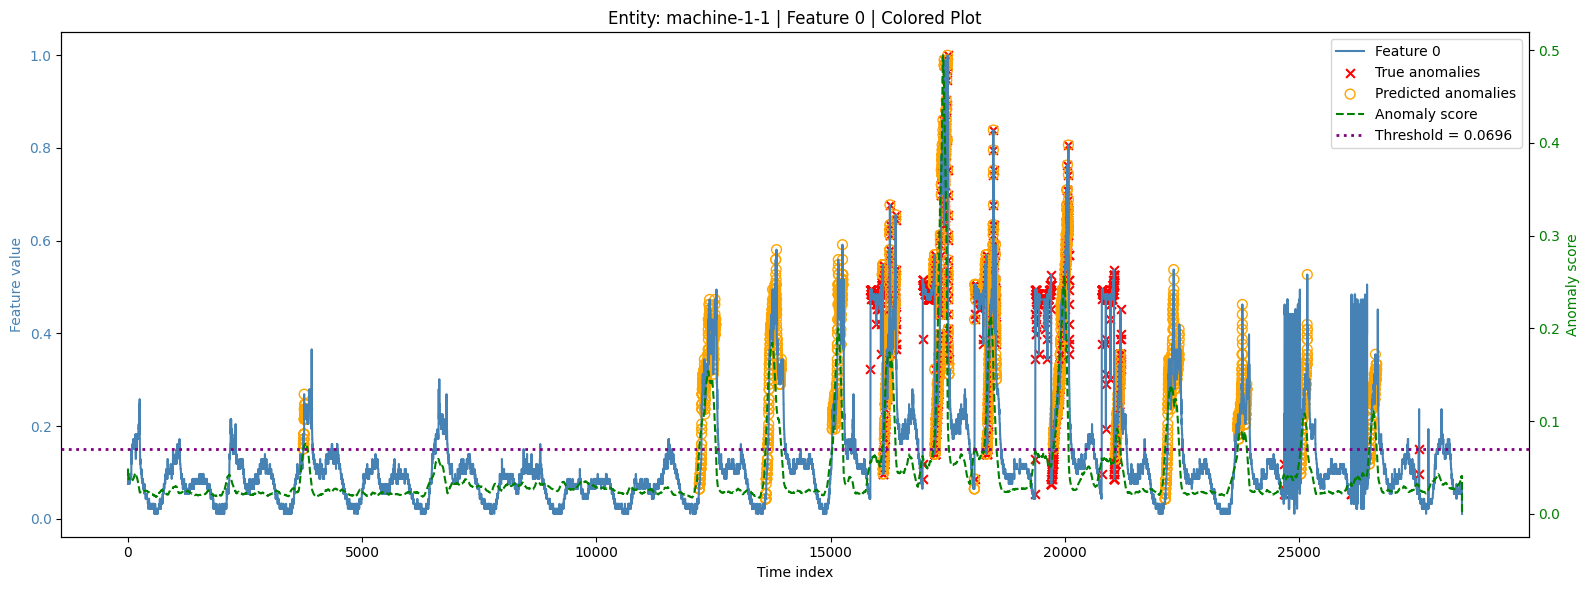

In [25]:
# %% [markdown]
# Step 9 - Plot time series, anomaly scores, true labels, and predictions (colored)

# %%
import matplotlib.pyplot as plt
import numpy as np

# 1) Get full test series and labels (point-level)
test_series_full = data_dict[entity]["test"]        # shape [T, D]
test_labels_full = data_dict[entity]["test_label"]  # shape [T]

T, D = test_series_full.shape
W = model_params["window_size"]
stride = model_params["stride"]

# 2) Expand window-level scores into point-level scores
point_scores = np.zeros(T, dtype=float)
point_counts = np.zeros(T, dtype=float)

for i, score in enumerate(test_anomaly_score):
    start = i * stride
    end = start + W
    if start >= T:
        break
    if end > T:
        end = T
    point_scores[start:end] += score
    point_counts[start:end] += 1.0

mask = point_counts > 0
point_scores[mask] /= point_counts[mask]

# 3) Derive point-level predictions
th = results["th"]*1.5
point_pred = np.zeros(T, dtype=int)
point_pred[mask] = (point_scores[mask] >= th).astype(int)

# 4) Choose feature index to plot
feature_idx = 0
ts = test_series_full[:, feature_idx]

time_idx = np.arange(T)

# 5) Plot with clear colors
fig, ax1 = plt.subplots(figsize=(16, 6))

# Raw time series (blue)
ax1.plot(time_idx, ts, color="steelblue", label=f"Feature {feature_idx}")

# True anomalies (red x marks)
true_anom_idx = np.where(test_labels_full == 1)[0]
ax1.scatter(
    true_anom_idx,
    ts[true_anom_idx],
    color="red",
    marker="x",
    s=40,
    label="True anomalies"
)

# Predicted anomalies (orange circles)
pred_anom_idx = np.where(point_pred == 1)[0]
ax1.scatter(
    pred_anom_idx,
    ts[pred_anom_idx],
    facecolors="none",
    edgecolors="orange",
    marker="o",
    s=50,
    label="Predicted anomalies"
)

ax1.set_xlabel("Time index")
ax1.set_ylabel("Feature value", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Right axis: anomaly score (green)
ax2 = ax1.twinx()
ax2.plot(time_idx, point_scores, color="green", linestyle="--", label="Anomaly score")

# Threshold (purple horizontal line)
ax2.axhline(
    th,
    color="purple",
    linestyle=":",
    linewidth=2,
    label=f"Threshold = {th:.4f}"
)

ax2.set_ylabel("Anomaly score", color="green")
ax2.tick_params(axis="y", labelcolor="green")

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(f"Entity: {entity} | Feature {feature_idx} | Colored Plot")
plt.tight_layout()
plt.show()


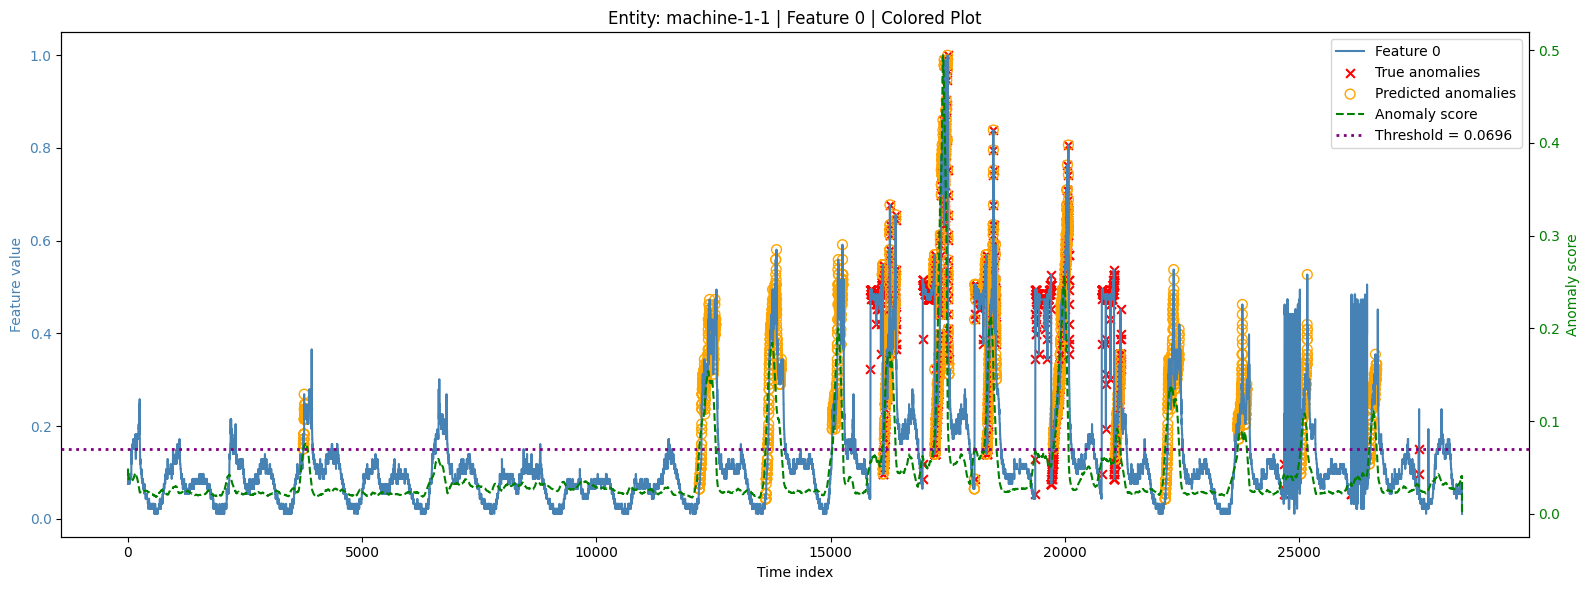

In [25]:
# %% [markdown]
# Step 9 - Plot time series, anomaly scores, true labels, and predictions (colored)

# %%
import matplotlib.pyplot as plt
import numpy as np

# 1) Get full test series and labels (point-level)
test_series_full = data_dict[entity]["test"]        # shape [T, D]
test_labels_full = data_dict[entity]["test_label"]  # shape [T]

T, D = test_series_full.shape
W = model_params["window_size"]
stride = model_params["stride"]

# 2) Expand window-level scores into point-level scores
point_scores = np.zeros(T, dtype=float)
point_counts = np.zeros(T, dtype=float)

for i, score in enumerate(test_anomaly_score):
    start = i * stride
    end = start + W
    if start >= T:
        break
    if end > T:
        end = T
    point_scores[start:end] += score
    point_counts[start:end] += 1.0

mask = point_counts > 0
point_scores[mask] /= point_counts[mask]

# 3) Derive point-level predictions
th = results["th"]*1.5
point_pred = np.zeros(T, dtype=int)
point_pred[mask] = (point_scores[mask] >= th).astype(int)

# 4) Choose feature index to plot
feature_idx = 0
ts = test_series_full[:, feature_idx]

time_idx = np.arange(T)

# 5) Plot with clear colors
fig, ax1 = plt.subplots(figsize=(16, 6))

# Raw time series (blue)
ax1.plot(time_idx, ts, color="steelblue", label=f"Feature {feature_idx}")

# True anomalies (red x marks)
true_anom_idx = np.where(test_labels_full == 1)[0]
ax1.scatter(
    true_anom_idx,
    ts[true_anom_idx],
    color="red",
    marker="x",
    s=40,
    label="True anomalies"
)

# Predicted anomalies (orange circles)
pred_anom_idx = np.where(point_pred == 1)[0]
ax1.scatter(
    pred_anom_idx,
    ts[pred_anom_idx],
    facecolors="none",
    edgecolors="orange",
    marker="o",
    s=50,
    label="Predicted anomalies"
)

ax1.set_xlabel("Time index")
ax1.set_ylabel("Feature value", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Right axis: anomaly score (green)
ax2 = ax1.twinx()
ax2.plot(time_idx, point_scores, color="green", linestyle="--", label="Anomaly score")

# Threshold (purple horizontal line)
ax2.axhline(
    th,
    color="purple",
    linestyle=":",
    linewidth=2,
    label=f"Threshold = {th:.4f}"
)

ax2.set_ylabel("Anomaly score", color="green")
ax2.tick_params(axis="y", labelcolor="green")

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(f"Entity: {entity} | Feature {feature_idx} | Colored Plot")
plt.tight_layout()
plt.show()


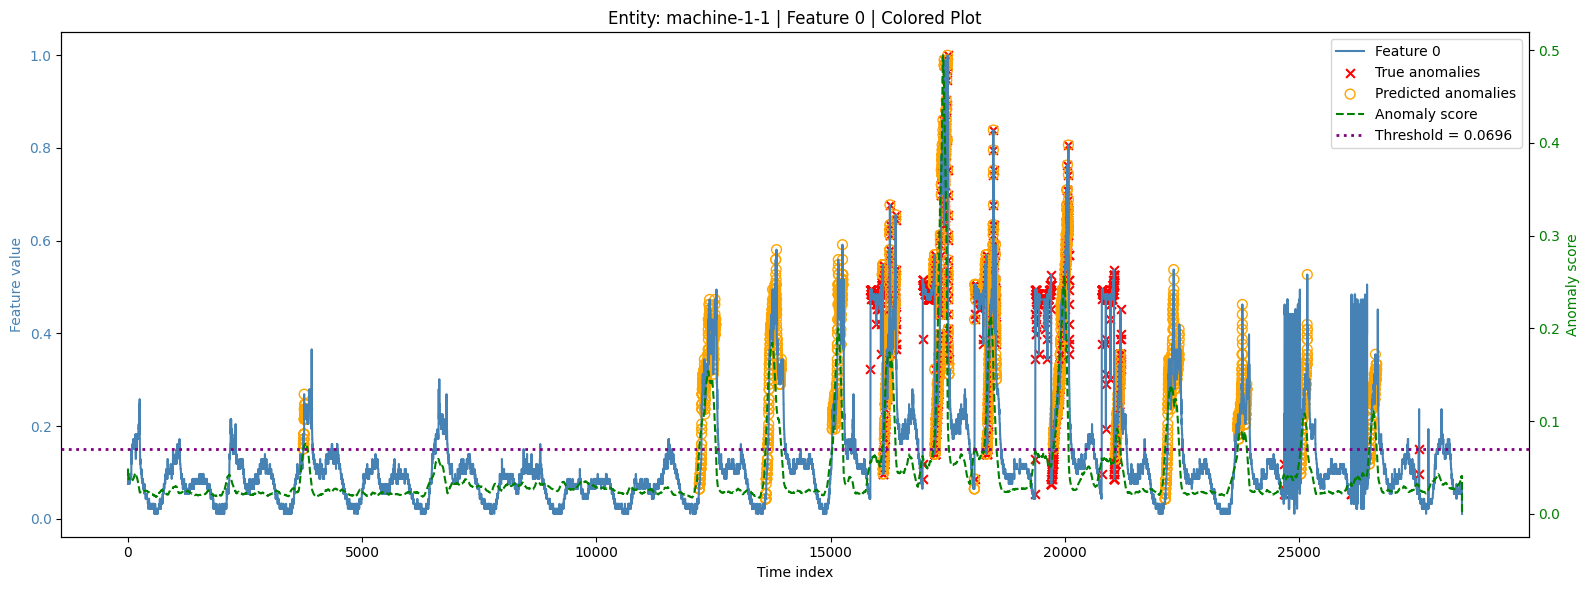

In [25]:
# %% [markdown]
# Step 9 - Plot time series, anomaly scores, true labels, and predictions (colored)

# %%
import matplotlib.pyplot as plt
import numpy as np

# 1) Get full test series and labels (point-level)
test_series_full = data_dict[entity]["test"]        # shape [T, D]
test_labels_full = data_dict[entity]["test_label"]  # shape [T]

T, D = test_series_full.shape
W = model_params["window_size"]
stride = model_params["stride"]

# 2) Expand window-level scores into point-level scores
point_scores = np.zeros(T, dtype=float)
point_counts = np.zeros(T, dtype=float)

for i, score in enumerate(test_anomaly_score):
    start = i * stride
    end = start + W
    if start >= T:
        break
    if end > T:
        end = T
    point_scores[start:end] += score
    point_counts[start:end] += 1.0

mask = point_counts > 0
point_scores[mask] /= point_counts[mask]

# 3) Derive point-level predictions
th = results["th"]*1.5
point_pred = np.zeros(T, dtype=int)
point_pred[mask] = (point_scores[mask] >= th).astype(int)

# 4) Choose feature index to plot
feature_idx = 0
ts = test_series_full[:, feature_idx]

time_idx = np.arange(T)

# 5) Plot with clear colors
fig, ax1 = plt.subplots(figsize=(16, 6))

# Raw time series (blue)
ax1.plot(time_idx, ts, color="steelblue", label=f"Feature {feature_idx}")

# True anomalies (red x marks)
true_anom_idx = np.where(test_labels_full == 1)[0]
ax1.scatter(
    true_anom_idx,
    ts[true_anom_idx],
    color="red",
    marker="x",
    s=40,
    label="True anomalies"
)

# Predicted anomalies (orange circles)
pred_anom_idx = np.where(point_pred == 1)[0]
ax1.scatter(
    pred_anom_idx,
    ts[pred_anom_idx],
    facecolors="none",
    edgecolors="orange",
    marker="o",
    s=50,
    label="Predicted anomalies"
)

ax1.set_xlabel("Time index")
ax1.set_ylabel("Feature value", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Right axis: anomaly score (green)
ax2 = ax1.twinx()
ax2.plot(time_idx, point_scores, color="green", linestyle="--", label="Anomaly score")

# Threshold (purple horizontal line)
ax2.axhline(
    th,
    color="purple",
    linestyle=":",
    linewidth=2,
    label=f"Threshold = {th:.4f}"
)

ax2.set_ylabel("Anomaly score", color="green")
ax2.tick_params(axis="y", labelcolor="green")

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(f"Entity: {entity} | Feature {feature_idx} | Colored Plot")
plt.tight_layout()
plt.show()


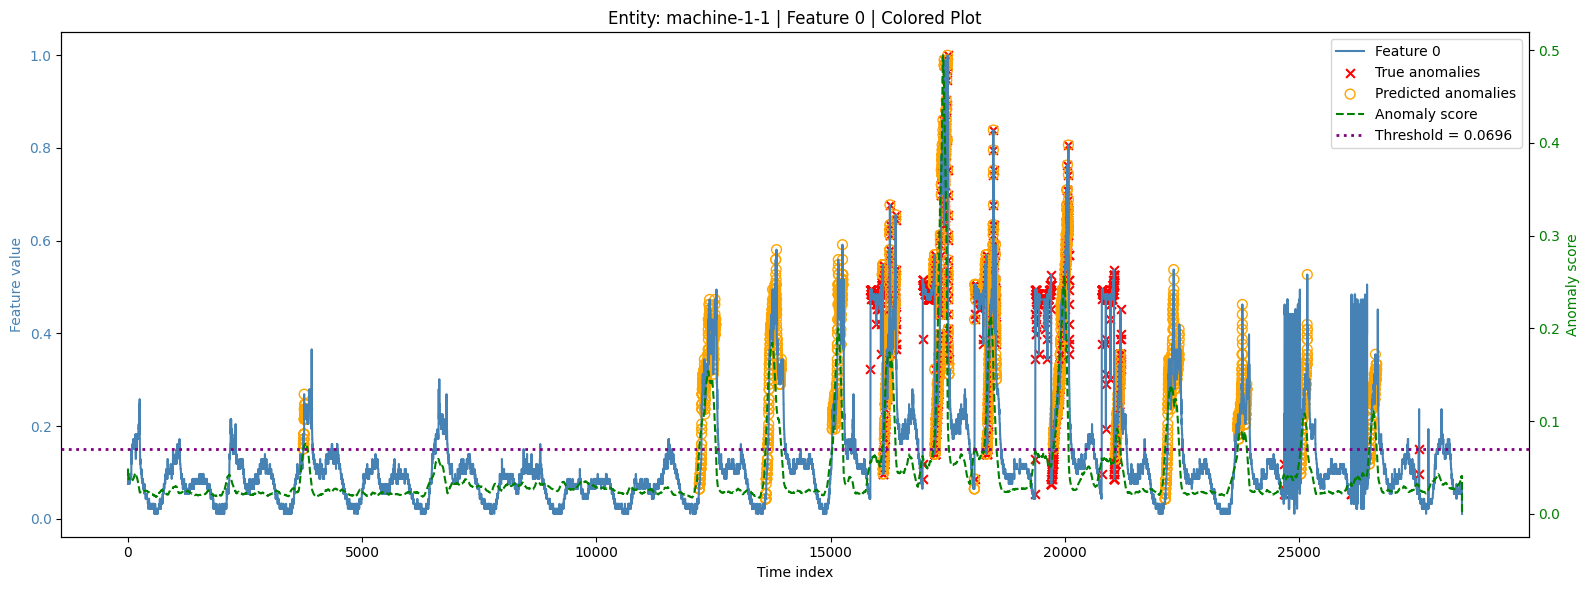

In [25]:
# %% [markdown]
# Step 9 - Plot time series, anomaly scores, true labels, and predictions (colored)

# %%
import matplotlib.pyplot as plt
import numpy as np

# 1) Get full test series and labels (point-level)
test_series_full = data_dict[entity]["test"]        # shape [T, D]
test_labels_full = data_dict[entity]["test_label"]  # shape [T]

T, D = test_series_full.shape
W = model_params["window_size"]
stride = model_params["stride"]

# 2) Expand window-level scores into point-level scores
point_scores = np.zeros(T, dtype=float)
point_counts = np.zeros(T, dtype=float)

for i, score in enumerate(test_anomaly_score):
    start = i * stride
    end = start + W
    if start >= T:
        break
    if end > T:
        end = T
    point_scores[start:end] += score
    point_counts[start:end] += 1.0

mask = point_counts > 0
point_scores[mask] /= point_counts[mask]

# 3) Derive point-level predictions
th = results["th"]*1.5
point_pred = np.zeros(T, dtype=int)
point_pred[mask] = (point_scores[mask] >= th).astype(int)

# 4) Choose feature index to plot
feature_idx = 0
ts = test_series_full[:, feature_idx]

time_idx = np.arange(T)

# 5) Plot with clear colors
fig, ax1 = plt.subplots(figsize=(16, 6))

# Raw time series (blue)
ax1.plot(time_idx, ts, color="steelblue", label=f"Feature {feature_idx}")

# True anomalies (red x marks)
true_anom_idx = np.where(test_labels_full == 1)[0]
ax1.scatter(
    true_anom_idx,
    ts[true_anom_idx],
    color="red",
    marker="x",
    s=40,
    label="True anomalies"
)

# Predicted anomalies (orange circles)
pred_anom_idx = np.where(point_pred == 1)[0]
ax1.scatter(
    pred_anom_idx,
    ts[pred_anom_idx],
    facecolors="none",
    edgecolors="orange",
    marker="o",
    s=50,
    label="Predicted anomalies"
)

ax1.set_xlabel("Time index")
ax1.set_ylabel("Feature value", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Right axis: anomaly score (green)
ax2 = ax1.twinx()
ax2.plot(time_idx, point_scores, color="green", linestyle="--", label="Anomaly score")

# Threshold (purple horizontal line)
ax2.axhline(
    th,
    color="purple",
    linestyle=":",
    linewidth=2,
    label=f"Threshold = {th:.4f}"
)

ax2.set_ylabel("Anomaly score", color="green")
ax2.tick_params(axis="y", labelcolor="green")

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(f"Entity: {entity} | Feature {feature_idx} | Colored Plot")
plt.tight_layout()
plt.show()
